In [1]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from sympy import Matrix, nsimplify, latex
from IPython.display import display

In [2]:
sqrt2 = np.sqrt(2)

# Bravais lattice constant
a = 1 + sqrt2

lat_sqoct = kwant.lattice.general(
    [(a, 0), (0, a)],  # lattice vectors

    [
        (1/sqrt2, 0),          # A
        (sqrt2, 1/sqrt2),      # B
        (1/sqrt2, sqrt2),      # C
        (0, 1/sqrt2)           # D
    ],

    norbs=1
)

A, B, C, D = lat_sqoct.sublattices

```
Within cell (i,j):

        C(i,j)
          ●
         / \
        /   \
 D(i,j) ●   ● B(i,j)
        \   /
         \ /
          ●
        A(i,j)


Inter-cell:

B(i,j) -------- D(i+1,j)

C(i,j)
   |
   |
A(i,j+1)
```

In [4]:
print("A:", A(0, 0).pos)
print("B:", B(0, 0).pos)
print("C:", C(0, 0).pos)
print("D:", D(0, 0).pos)

A: [0.7071067811865475 0.0]
B: [1.4142135623730951 0.7071067811865475]
C: [0.7071067811865475 1.4142135623730951]
D: [0.0 0.7071067811865475]


In [11]:
Nx = 2
Ny = 2

syst = kwant.Builder()

onsite = 0.0

for i in range(Nx):
    for j in range(Ny):

        syst[A(i, j)] = onsite
        syst[B(i, j)] = onsite
        syst[C(i, j)] = onsite
        syst[D(i, j)] = onsite

t = -1.0

for i in range(Nx):
    for j in range(Ny):

        syst[A(i, j), B(i, j)] = t
        syst[B(i, j), C(i, j)] = t
        syst[C(i, j), D(i, j)] = t
        syst[D(i, j), A(i, j)] = t

# Until now we have isolated tilted squares as the squares have not been connected to each other
# kwant.plot(syst);

Along the \(x\)-direction, the right site \(B\) connects to the left site \(D\) of the next unit cell:

$$
B(i,j)\longleftrightarrow D(i+1,j).
$$

Along the \(y\)-direction, the top site \(C\) connects to the bottom site \(A\) of the unit cell above:

$$
C(i,j)\longleftrightarrow A(i,j+1).
$$

In [12]:
for i in range(Nx):
    for j in range(Ny):

        # Connect to next unit cell along x
        if i < Nx - 1:
            syst[B(i, j), D(i + 1, j)] = t

        # Connect to next unit cell along y
        if j < Ny - 1:
            syst[C(i, j), A(i, j + 1)] = t

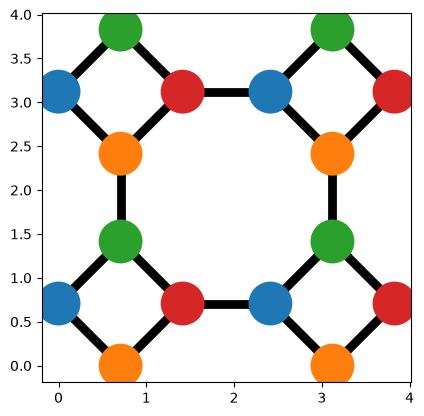

In [13]:
kwant.plot(syst);

In [14]:
fsyst = syst.finalized()

H = fsyst.hamiltonian_submatrix()
H = Matrix(H).applyfunc(nsimplify)
H

Matrix([
[ 0,  0,  0,  0, -1,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0],
[ 0,  0,  0,  0,  0, -1,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0],
[ 0,  0,  0,  0,  0,  0, -1,  0,  0,  0, -1,  0, -1,  0,  0,  0],
[ 0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0, -1,  0, -1,  0,  0],
[-1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0],
[ 0, -1,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0, -1,  0,  0],
[ 0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0],
[ 0,  0,  0, -1,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0, -1],
[-1,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0],
[ 0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0],
[ 0,  0, -1,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0, -1,  0],
[ 0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1],
[ 0,  0, -1,  0, -1,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0],
[ 0,  0,  0, -1,  0, -1,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0],
[ 0,  0,  0,  0,  0,  0, -1,  0,  0,  0, -1,  0,  0,  0,  0,  0],
[

## Periodic Boundary Condition

In [15]:
sqrt2 = np.sqrt(2)
a = 1 + sqrt2

lat_sqoct = kwant.lattice.general(
    [(a, 0), (0, a)],
    [
        (1/sqrt2, 0),       # A
        (sqrt2, 1/sqrt2),   # B
        (1/sqrt2, sqrt2),   # C
        (0, 1/sqrt2)        # D
    ],
    norbs=1
)

A, B, C, D = lat_sqoct.sublattices

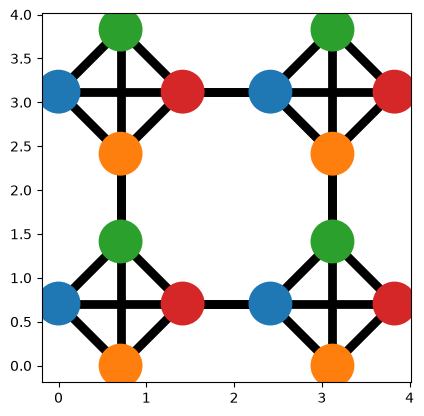

In [16]:
Nx = 2
Ny = 2

onsite = 0.0
t = -1.0

syst = kwant.Builder()

# Add sites
for i in range(Nx):
    for j in range(Ny):
        syst[A(i, j)] = onsite
        syst[B(i, j)] = onsite
        syst[C(i, j)] = onsite
        syst[D(i, j)] = onsite

# Add hoppings with PBC
for i in range(Nx):
    for j in range(Ny):

        # Intra-cell square
        syst[A(i, j), B(i, j)] = t
        syst[B(i, j), C(i, j)] = t
        syst[C(i, j), D(i, j)] = t
        syst[D(i, j), A(i, j)] = t

        # Inter-cell x direction
        syst[B(i, j), D((i + 1) % Nx, j)] = t

        # Inter-cell y direction
        syst[C(i, j), A(i, (j + 1) % Ny)] = t

kwant.plot(syst);

In [17]:
fsyst = syst.finalized()

H = fsyst.hamiltonian_submatrix()
H = Matrix(H).applyfunc(nsimplify)
H

Matrix([
[ 0,  0,  0,  0, -1,  0,  0,  0, -1,  0,  0,  0,  0,  0, -1,  0],
[ 0,  0,  0,  0,  0, -1,  0,  0,  0, -1,  0,  0,  0,  0,  0, -1],
[ 0,  0,  0,  0,  0,  0, -1,  0,  0,  0, -1,  0, -1,  0,  0,  0],
[ 0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0, -1,  0, -1,  0,  0],
[-1,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0, -1,  0,  0,  0],
[ 0, -1,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0, -1,  0,  0],
[ 0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0, -1,  0],
[ 0,  0,  0, -1,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0, -1],
[-1,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0],
[ 0, -1,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0],
[ 0,  0, -1,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0, -1,  0],
[ 0,  0,  0, -1,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0, -1],
[ 0,  0, -1,  0, -1,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0],
[ 0,  0,  0, -1,  0, -1,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0],
[-1,  0,  0,  0,  0,  0, -1,  0,  0,  0, -1,  0,  0,  0,  0,  0],
[